In [10]:
# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
# Step 2: Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Raw shapes:", x_train.shape, y_train.shape, x_test.shape, y_test.shape)
# (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)

Raw shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [12]:
# Step 3: Normalize and reshape the image data
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)   # shape -> (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test, -1)    # shape -> (10000, 28, 28, 1)

In [13]:
# Step 4: Convert labels to one-hot encoded vectors
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

#Create a validation split (pull 10k from train for validation)
val_size = 10000
x_val = x_train[-val_size:]
y_val = y_train_cat[-val_size:]
x_train = x_train[:-val_size]
y_train_cat = y_train_cat[:-val_size]

print("Train / Val / Test shapes:", x_train.shape, y_train_cat.shape, x_val.shape, y_val.shape, x_test.shape)

Train / Val / Test shapes: (50000, 28, 28, 1) (50000, 10) (10000, 28, 28, 1) (10000, 10) (10000, 28, 28, 1)


In [14]:
# Step 5: Build CNN model
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [15]:
# Step 6: Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 12, 12, 64)       0         
 2D)                                                             
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten_1 (Flatten)         (None, 9216)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               1179776   
                                                      

In [17]:
# Step 7: Train the model
epochs = 12
batch_size = 128

history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=2
)



Epoch 1/12
391/391 - 35s - loss: 0.2693 - accuracy: 0.9177 - val_loss: 0.0709 - val_accuracy: 0.9799 - 35s/epoch - 89ms/step
Epoch 2/12
391/391 - 34s - loss: 0.0940 - accuracy: 0.9724 - val_loss: 0.0529 - val_accuracy: 0.9849 - 34s/epoch - 88ms/step
Epoch 3/12
391/391 - 33s - loss: 0.0688 - accuracy: 0.9794 - val_loss: 0.0429 - val_accuracy: 0.9888 - 33s/epoch - 85ms/step
Epoch 4/12
391/391 - 35s - loss: 0.0556 - accuracy: 0.9830 - val_loss: 0.0377 - val_accuracy: 0.9890 - 35s/epoch - 91ms/step
Epoch 5/12
391/391 - 35s - loss: 0.0463 - accuracy: 0.9854 - val_loss: 0.0351 - val_accuracy: 0.9895 - 35s/epoch - 89ms/step
Epoch 6/12
391/391 - 35s - loss: 0.0410 - accuracy: 0.9874 - val_loss: 0.0376 - val_accuracy: 0.9895 - 35s/epoch - 89ms/step
Epoch 7/12
391/391 - 35s - loss: 0.0368 - accuracy: 0.9878 - val_loss: 0.0361 - val_accuracy: 0.9890 - 35s/epoch - 89ms/step
Epoch 8/12
391/391 - 35s - loss: 0.0342 - accuracy: 0.9887 - val_loss: 0.0340 - val_accuracy: 0.9913 - 35s/epoch - 90ms/step


In [18]:
# Step 8: Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest loss: {test_loss:.4f} — Test accuracy: {test_acc:.4f}")


313/313 - 2s - loss: 0.0273 - accuracy: 0.9922 - 2s/epoch - 6ms/step

Test loss: 0.0273 — Test accuracy: 0.9922


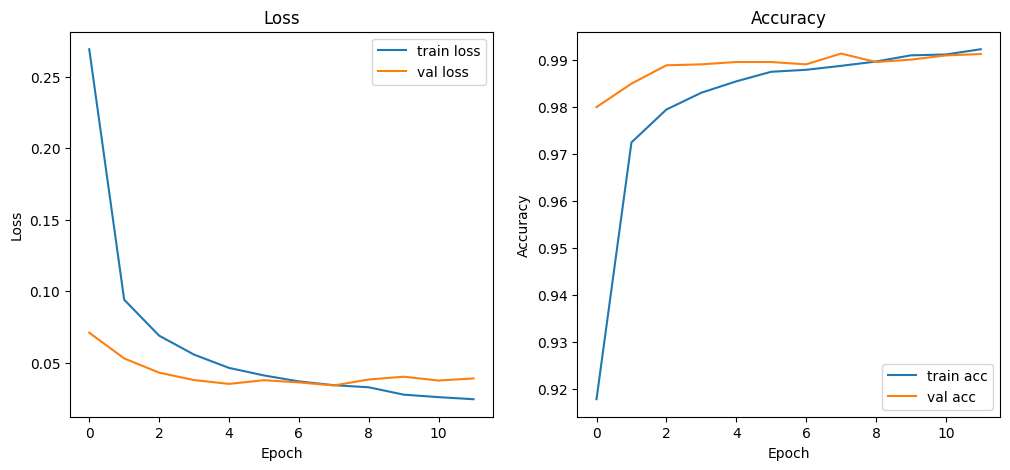

In [19]:
# Step 9: Display training accuracy graph
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend()
plt.show()

In [26]:
#Step 10: Make predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

313/313 [==============================] - 2s 6ms/step


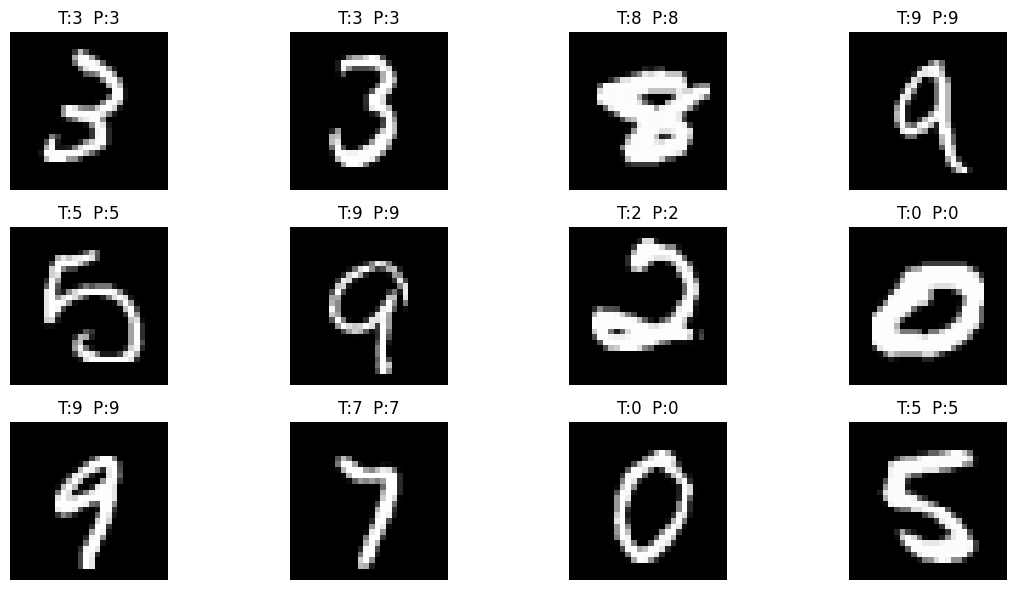

In [27]:
# Step 11: Visualize some sample predictions
n_samples = 12
idxs = np.random.choice(len(x_test), n_samples, replace=False)

plt.figure(figsize=(12,6))
for i, idx in enumerate(idxs):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"T:{y_true[idx]}  P:{y_pred[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
